使用 messages 流式模式从图中的任何部分（包括节点、工具、子图或任务）按 token 逐个流式传输大语言模型的输出。

来自 messages 模式的流式输出是一个元组 `(message_chunk, metadata)`

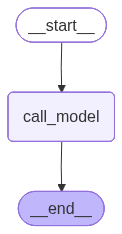

In [1]:
from dataclasses import dataclass
from agent_lab.model_hub import LLM_FAST
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


@dataclass
class MyState:
    topic: str
    joke: str = ""


model = init_chat_model(**LLM_FAST)

def call_model(state: MyState):
    """Call the LLM to generate a joke about a topic"""
    # Note that message events are emitted even when the LLM is run using .invoke rather than .stream
    model_response = model.invoke(
        [
            {"role": "user", "content": f"Generate a joke about {state.topic}"}
        ]
    )
    return {"joke": model_response.content}

graph = (
    StateGraph(MyState)
    .add_node(call_model)
    .add_edge(START, "call_model")
    .add_edge("call_model", END)
    .compile()
)
display(Image(graph.get_graph().draw_mermaid_png()))

In [2]:

# The "messages" stream mode streams LLM tokens with metadata
# Use version="v2" for a unified StreamPart format
for chunk in graph.stream(
    {"topic": "ice cream"}, # type: ignore
    stream_mode="messages",
    version="v2",
):
    if chunk["type"] == "messages":
        message_chunk, metadata = chunk["data"]
        if message_chunk.content:
            print(message_chunk.content, end="|", flush=True)

Why| did| the| ice| cream| go| to| therapy|?

|It| had| too| many| sprink|les| of| anxiety| and| a| rocky| road| ahead|.|

#### 按模型标签异步调用

In [3]:
from typing import TypedDict


# The joke_model is tagged with "joke"
joke_model = init_chat_model(**LLM_FAST, tags=["joke"])
# The poem_model is tagged with "poem"
poem_model = init_chat_model(**LLM_FAST, tags=["poem"])


class State(TypedDict):
      topic: str
      joke: str
      poem: str


async def call_model(state, config):
      topic = state["topic"]
      print("Writing joke...")
      joke_response = await joke_model.ainvoke(
            [{"role": "user", "content": f"Write a joke about {topic}"}],
            config,
      )
      print("\n\nWriting poem...")
      poem_response = await poem_model.ainvoke(
            [{"role": "user", "content": f"Write a short poem about {topic}"}],
            config,
      )
      return {"joke": joke_response.content, "poem": poem_response.content}


graph = (
      StateGraph(State)
      .add_node(call_model)
      .add_edge(START, "call_model")
      .add_edge("call_model", END)
      .compile()
)

In [4]:
# The stream_mode is set to "messages" to stream LLM tokens
# The metadata contains information about the LLM invocation, including the tags
async for chunk in graph.astream(
      {"topic": "cats"}, # type: ignore
      stream_mode="messages",
      version="v2",
):
    if chunk["type"] == "messages":
        msg, metadata = chunk["data"]
        if metadata["tags"] == ["joke"]:
            print(msg.content, end="|", flush=True)

Writing joke...
|Why| did| the| cat| break| up| with| the| laser| pointer|?

|Because| it| realized| the| relationship| was| completely| one|-sided| and| kept| chasing| red| flags|.|||

Writing poem...


#### 从流中省略消息

带有 nostream 标签的调用仍然会运行并产生输出；只是它们的 token 在 messages 模式下不会被发送。

In [ ]:
from typing import Any


stream_model = init_chat_model(**LLM_FAST)
internal_model = init_chat_model(**LLM_FAST).with_config(
    {"tags": ["nostream"]}
)


class State(TypedDict):
    topic: str
    answer: str
    notes: str


def answer(state: State) -> dict[str, Any]:
    print("\nGenerating answer...")
    r = stream_model.invoke(
        [{"role": "user", "content": f"Reply briefly about {state['topic']}"}]
    )
    return {"answer": r.content}


def internal_notes(state: State) -> dict[str, Any]:
    print("\nGenerating internal notes...")
    # Tokens from this model are omitted from stream_mode="messages" because of nostream
    r = internal_model.invoke(
        [{"role": "user", "content": f"Private notes on {state['topic']}"}]
    )
    return {"notes": r.content}


graph = (
    StateGraph(State)
    .add_node("write_answer", answer)
    .add_node("internal_notes", internal_notes)
    .add_edge(START, "write_answer")
    .add_edge("write_answer", "internal_notes")
    .add_edge("internal_notes", END)
    .compile()
)

In [13]:
initial_state: State = {"topic": "AI", "answer": "", "notes": ""}
for chunk in graph.stream(initial_state, stream_mode="messages", version="v2"):
    if chunk["type"] == "messages":
        msg, metadata = chunk["data"]
        print(msg.content, end="|", flush=True)


Generating answer...
|AI| refers| to| computer| systems| designed| to| mimic| human| intelligence| for| tasks| like| learning|,| reasoning|,| and| problem|-solving|.| It| powers| tools| like| chatbots|,| recommendations|,| and| automation|.| Key| risks| include| bias|,| job| displacement|,| and| ethical| concerns|.|||
Generating internal notes...


#### 按节点过滤

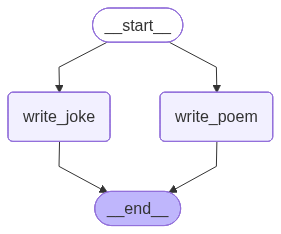

In [14]:
model = init_chat_model(**LLM_FAST)


class State(TypedDict):
      topic: str
      joke: str
      poem: str


def write_joke(state: State):
      topic = state["topic"]
      joke_response = model.invoke(
            [{"role": "user", "content": f"Write a joke about {topic}"}]
      )
      return {"joke": joke_response.content}


def write_poem(state: State):
      topic = state["topic"]
      poem_response = model.invoke(
            [{"role": "user", "content": f"Write a short poem about {topic}"}]
      )
      return {"poem": poem_response.content}


graph = (
      StateGraph(State)
      .add_node(write_joke)
      .add_node(write_poem)
      # write both the joke and the poem concurrently
      .add_edge(START, "write_joke")
      .add_edge(START, "write_poem")
      .add_edge("write_joke", END)
      .add_edge("write_poem", END)
      .compile()
)
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
# The "messages" stream mode streams LLM tokens with metadata
# Use version="v2" for a unified StreamPart format
for chunk in graph.stream(
    {"topic": "cats"}, # type: ignore
    stream_mode="messages",
    version="v2",
):
    if chunk["type"] == "messages":
        msg, metadata = chunk["data"]
        # Filter the streamed tokens by the langgraph_node field in the metadata
        # to only include the tokens from the write_poem node
        if msg.content and metadata["langgraph_node"] == "write_poem":
            print(msg.content, end="|", flush=True)

A| flick| of| tail|,| a| silent| leap|,
|On| padded| paws|,| where| shadows| sleep|.
|A| golden| eye|,| a| crescent| stare|,
|At| dust| mot|es| dancing| in| the| air|.

|A| pur|r|,| a| rum|ble|,| deep| and| low|,
|A| single| truth| the| whole| world| knows|:
|The| throne| is| theirs|,| the| lap| is| lent|,
|And| we| are| merely| heaven|-s|ent|.|